First Check if Internet is working

In [1]:
import socket, warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1',53))
except socket.error as ex:
    raise Exception("No Internet")

Now we will search bird photos on duckduckgo 

In [8]:
import time
from ddgs import DDGS
from fastai.vision.all import *

def search_images(keywords, max_images=200, retries=3, delay=10):
    for attempt in range(retries):
        try:
            return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            time.sleep(delay)
    raise Exception("All retries failed — DDG may be blocking this IP for a while")

urls = search_images('bird photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg'

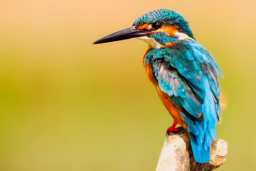

In [12]:
from fastdownload import download_url
dest = 'pexels-photo-326900.jpeg'
download_url(urls[0], show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256)

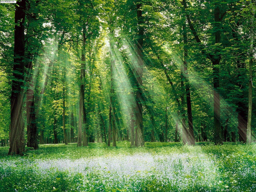

In [20]:
Image.open('forest.png').to_thumb(256,256)

In [21]:
searches = 'forest', 'bird'
path = Path('bird_or_not')
for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

some photos might not download correctly so we remove them 

In [22]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

To train a model, we'll need DataLoaders, which is an object that contains a training set and a validation set 

d:\Python313\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
d:\Python313\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
d:\Python313\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' a

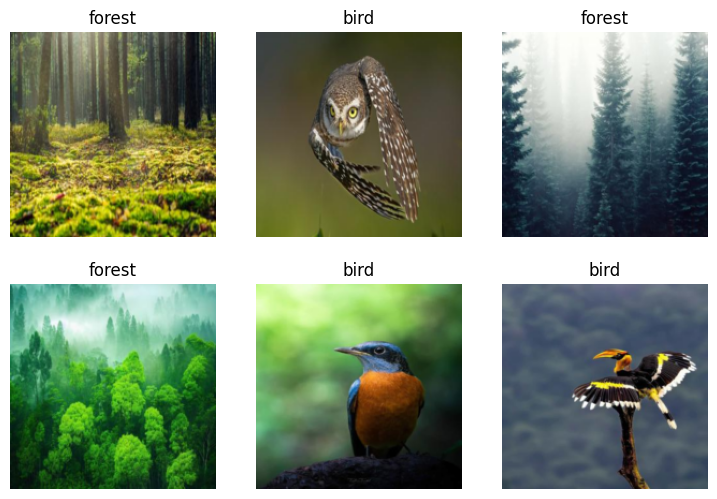

In [23]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

now train the resnet model

In [24]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ssa56/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.53MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.054449,4.394649,0.666667,00:26


epoch,train_loss,valid_loss,error_rate,time
0,0.892658,3.369079,0.666667,00:27
1,0.723563,2.591121,0.583333,00:24
2,0.487445,1.885224,0.500000,00:25


Now test our model

In [26]:
is_bird,_,probs = learn.predict(PILImage.create('pexels-photo-326900.jpeg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")


<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

This is a: bird.
Probability it's a bird: 1.0000
